## Using LLM to extract answers script

Author: Sahana Kowshik

Date: 05/07/2025

In [1]:
import os
os.environ['HF_HOME'] = '/projectnb/vkolagrp/skowshik/.cache/'
import torch
import torch.nn.functional as F
import argparse
import pandas as pd
import numpy as np
import torch.distributed as dist
import json
import warnings
import random
import time
import string
warnings.filterwarnings("ignore")
import re

from tqdm import tqdm
from datetime import timedelta
from collections import OrderedDict
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams
os.environ['VLLM_SKIP_P2P_CHECK'] = "1"

INFO 05-07 19:15:21 [__init__.py:239] Automatically detected platform cuda.


In [2]:
# model_id = 'Qwen/Qwen2.5-14B-Instruct'
model_id = 'Qwen/Qwen3-14B'
n_devices = 2
max_model_len = 5000

In [3]:
# data = pd.read_csv("/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.csv")

In [4]:
def load_model(model_id, n_devices, max_model_len):
    """Load VLLM model and Huggingface tokenizer."""
    llm = LLM(
        model=model_id,
        tokenizer=model_id,
        tensor_parallel_size=n_devices,
        gpu_memory_utilization=0.9,
        max_model_len=max_model_len,
        enable_lora=False,
        distributed_executor_backend='mp',
    )
    
    tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side='left')
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        
    return llm, tokenizer

In [5]:
llm, tokenizer = load_model(model_id, n_devices, max_model_len)

INFO 05-07 19:15:43 [config.py:717] This model supports multiple tasks: {'score', 'reward', 'embed', 'generate', 'classify'}. Defaulting to 'generate'.
INFO 05-07 19:15:43 [config.py:2003] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 05-07 19:15:45 [core.py:58] Initializing a V1 LLM engine (v0.8.5.post1) with config: model='Qwen/Qwen3-14B', speculative_config=None, tokenizer='Qwen/Qwen3-14B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=5000, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='auto', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, colle

Loading safetensors checkpoint shards:   0% Completed | 0/8 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  12% Completed | 1/8 [00:00<00:02,  3.23it/s]
Loading safetensors checkpoint shards:  25% Completed | 2/8 [00:00<00:02,  2.81it/s]
Loading safetensors checkpoint shards:  38% Completed | 3/8 [00:00<00:01,  3.52it/s]
Loading safetensors checkpoint shards:  50% Completed | 4/8 [00:01<00:01,  3.47it/s]
Loading safetensors checkpoint shards:  62% Completed | 5/8 [00:01<00:00,  3.07it/s]
Loading safetensors checkpoint shards:  75% Completed | 6/8 [00:01<00:00,  2.84it/s]
Loading safetensors checkpoint shards:  88% Completed | 7/8 [00:02<00:00,  2.73it/s]


(VllmWorker rank=1 pid=332648) INFO 05-07 19:15:55 [loader.py:458] Loading weights took 2.83 seconds


Loading safetensors checkpoint shards: 100% Completed | 8/8 [00:02<00:00,  2.65it/s]
Loading safetensors checkpoint shards: 100% Completed | 8/8 [00:02<00:00,  2.87it/s]
(VllmWorker rank=0 pid=332647) 


(VllmWorker rank=0 pid=332647) INFO 05-07 19:15:55 [loader.py:458] Loading weights took 2.85 seconds
(VllmWorker rank=1 pid=332648) INFO 05-07 19:15:55 [gpu_model_runner.py:1347] Model loading took 13.8818 GiB and 3.790011 seconds
(VllmWorker rank=0 pid=332647) INFO 05-07 19:15:55 [gpu_model_runner.py:1347] Model loading took 13.8818 GiB and 3.896928 seconds
(VllmWorker rank=0 pid=332647) (VllmWorker rank=1 pid=332648) INFO 05-07 19:16:21 [backends.py:420] Using cache directory: /usr3/graduate/skowshik/.cache/vllm/torch_compile_cache/d3baaa677b/rank_0_0 for vLLM's torch.compile
INFO 05-07 19:16:21 [backends.py:420] Using cache directory: /usr3/graduate/skowshik/.cache/vllm/torch_compile_cache/d3baaa677b/rank_1_0 for vLLM's torch.compile
(VllmWorker rank=0 pid=332647) (VllmWorker rank=1 pid=332648) INFO 05-07 19:16:21 [backends.py:430] Dynamo bytecode transform time: 25.45 s
INFO 05-07 19:16:21 [backends.py:430] Dynamo bytecode transform time: 25.45 s
(VllmWorker rank=0 pid=332647) INFO

In [20]:
def get_vllm_summary(llm, tokenizer, messages, max_new_tokens=3000):
    """This is a function to generate LLAMA summaries using vllm https://github.com/vllm-project/vllm

    Args:
        llm: LLM object
        tokenizer: Huggingface tokenizer
        input_texts (List): A list of input texts / prompts
        system_msg (str): system message for the LLAMA prompt

    Returns:
        List: A list of generated responses
    """
    
    # return "Answer"
    

    prompts = []
    responses = []
    
    for message in messages:
        input_ids = tokenizer.apply_chat_template(
            message,
            add_generation_prompt=True,
            tokenize=False,
            continue_final_message=False,
            enable_thinking=False
            # return_tensors="pt"
        )
        
        prompts.append(input_ids)
    
    # https://github.com/vllm-project/vllm/blob/main/vllm/sampling_params.py#L38-L66
    sampling_params = SamplingParams(
        temperature=0.7,
        top_p=0.8,
        top_k=20,
        min_p=0,
        max_tokens=max_new_tokens,
        # frequency_penalty=0.5,
        # stop=stop_tokens
    )
    
    completions = llm.generate(
        prompts=prompts,
        sampling_params=sampling_params,
    )
    
    for i, output in enumerate(completions):
        temp_gen = output.outputs[0].text
        responses.append(temp_gen)
        
    # print('Successfully finished generating', len(prompts), 'samples!')
    
    return responses

In [21]:
def generate_summary(answers_dicts, llm, tokenizer, max_new_tokens=2048):
    """
    Generate summaries for patient data using a language model.
    
    Args:
    - patient_files: List of strings containing JSON-encoded patient data.
    - system_msg: Initial system message for the language model.
    - llm, tokenizer: Language model and tokenizer for generating summaries.

    Returns:
    - List of patient summaries.
    """
    messages = []
    for answers_dict in answers_dicts:
        message = [
            # {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
            {"role": "user", "content": EXTRACT_ANSWER_PROMPT.format(answer=answers_dict['answer'], question=answers_dict['question'], option=answers_dict['option'])}
        ]
        messages.append(message)
        
    extracted_answers = get_vllm_summary(llm, tokenizer, messages, max_new_tokens=max_new_tokens)
    
    return extracted_answers

In [22]:
def extract_answer_letter(text):
    """
    Extracts the single-letter answer from a string in the format 'ANSWER: X'.

    Args:
        text (str): Input string, e.g., 'ANSWER: B'

    Returns:
        str or None: Extracted answer letter, or None if no match is found.
    """
    match = re.search(r'ANSWER:\s*([A-Z])', text)
    if match:
        return match.group(1)
    return None

In [23]:
def extract_naccid(row):
    naccid = row['problem']['NACCID']
    row['NACCID'] = naccid
    return row

def load_results(file_path):
    results = []

    with open(file_path,'r') as f:
        for line in f:
            results.append(json.loads(line))

    results_df = pd.DataFrame(results).explode(['generated_text','finish_reason'])
    results_df = results_df.apply(extract_naccid, axis=1)
    results_df['UNQ_ID'] = [i for i in range(len(results_df))]
    
    return results_df

In [24]:
def extract_final_answer(text):
    # match = re.search(r'<answer>\n(Answer: )([a-zA-Z])\n</answer>', text, re.DOTALL)
    match = re.search(r'<answer>.*\s*(Answer: )([a-zA-Z]).*\s*</answer>', text, re.DOTALL)
    # match = re.search(r'.*\s*(Answer: )([a-zA-Z]).*\s*', text, re.DOTALL)
    return match.group(2).strip().upper() if match else 'invalid'

# def extract_answers(results_df, name, option_keys):
#     results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer)
#     results_df['ground_truth'] = [p['answer'] for p in results_df.problem]
#     results_df['prediction'] = results_df['prediction']#.replace({'N':'B','Y':'A'})
#     invalid_before[name] = len(results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))])
#     results_df = results_df[(results_df['prediction'] != 'invalid') & (results_df['prediction'].isin(option_keys))].reset_index(drop=True)
#     results_df.index = results_df.groupby('NACCID', sort=False).ngroup()
#     return results_df

def extract_answers(results_df, name, option_keys):
    results_df['prediction'] = results_df['generated_text'].apply(extract_final_answer)
    invalid_df = results_df[(results_df['prediction'] == 'invalid') | (~results_df['prediction'].isin(option_keys))].reset_index(drop=True)
    invalid_df['extraction_type'] = "llm"
    valid_df = results_df[~results_df['UNQ_ID'].isin(invalid_df['UNQ_ID'])].reset_index(drop=True)
    valid_df['extraction_type'] = "regex"
    # valid_df['ground_truth'] = [p['answer'] for p in valid_df.problem]
    # valid_df.index = valid_df.groupby('NACCID', sort=False).ngroup()
    # return valid_df
    assert len(valid_df) + len(invalid_df) == len(results_df)
    
    invalid_before[name] = len(invalid_df)
    options = [options_list for _ in range(len(invalid_df))]
    answers = list(invalid_df['generated_text'])
    questions = [problem['question'] for problem in list(invalid_df['problem'])]
    answer_dicts = [
        {
            'answer': answers[i],
            'option': options[i],
            'question': questions[i]
        } for i in range(len(invalid_df))
    ]
    extracted_answers = generate_summary(answer_dicts, llm, tokenizer, max_new_tokens=100)
    extracted_answer_letters = [extract_answer_letter(answer) for answer in extracted_answers]
    extracted_answer_letters = [answer if answer != 'D' else 'invalid' for answer in extracted_answer_letters]
    invalid_df['prediction'] = extracted_answer_letters
    llm_answers[name] = extracted_answers
    
    results_df = pd.concat([valid_df, invalid_df], axis=0).sort_values(by='NACCID').reset_index(drop=True)
    invalid_after[name] = len(results_df[results_df['prediction'] == 'invalid'])
    results_df = results_df[results_df['prediction'] != 'invalid'].reset_index(drop=True)
    results_df['ground_truth'] = [p['answer'] for p in results_df.problem]
    results_df.index = results_df.groupby('NACCID', sort=False).ngroup()
    return results_df

In [25]:
def modify(results_df, n):
    
    results_combined = results_df.copy()[['prediction','ground_truth']]
    results_combined['prediction'] = results_combined['prediction']#.replace({'Y': 'A', 'N': 'B'})
    # results_combined['ground_truth'] = results_combined['ground_truth']#.replace({'Yes': 'A', 'No': 'B'})
    results_combined['correctness'] = results_combined['prediction'] == results_combined['ground_truth']
    p = len(results_combined) // n
    # results_combined['run'] = list(range(1,p+1))*n
    results_combined = results_combined.reset_index(names=['problem']).reset_index(drop=True)
    return results_combined

In [26]:
def pass_at_k(df, n, k=1): 
    """ 
    :param n: total number of samples 
    :param c: number of correct samples 
    :param k: k in pass@$k$ """
    
    cs = df.groupby('problem').sum('correctness')
    vals = []
    for i, row in cs.iterrows():
        c = row['correctness']
        # print(n,c,k)
        if n - c < k: vals.append(1.0)
        else: vals.append(1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1)))
         
    # print(vals)
    return np.mean(vals)

In [27]:
def get_passat1(df):
    return df.groupby('problem').mean('correctness')[['correctness']].mean().iloc[0]

def get_consatk(df, n):
    return (
        df.groupby('problem')['prediction']
        .apply(lambda x: x.mode()[0]) == 
        df[['problem', 'ground_truth']].drop_duplicates('problem', keep='first')['ground_truth'].reset_index(drop=True)
    ).sum() / n

def combine_results(results_dict, n, k):
    final_dict = {'metric': ['pass@1', 'cons@k']}
    for key, v in results_dict.items():
        # final_dict[k] = [get_passat1(v), get_consat5(v)]
        # print(get_passat1(v), get_consat5(v))
        p = len(v) // n
        final_dict[key] = [pass_at_k(v, p, k), get_consatk(v, n)]
        
        # print(pass_at_k(v, 5, 1), get_consat5(v))
        # raise ValueError

    # Create a tidy DataFrame
    df = pd.DataFrame(final_dict)
    
    return df

In [28]:
def get_mean_length(df):
    lengths = []
    for i, row in df.iterrows():
        lengths.append(len(row['generated_text'].split(" ")))
        
    return sum(lengths) / len(lengths)

In [29]:
# data_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-04-04T134012_1b22e7e417a94d74/qwen3b_adrd_cog_status_output.jsonl"
# data = extract_answers(load_results(data_path))
# data = data.reset_index(drop=True)

In [30]:
# data['extraction_type'].value_counts()

In [31]:
# data[data['extraction_type'] == 'llm']

In [32]:
# print(data.iloc[4946]['generated_text'])

In [34]:
# Cognitive status
qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T140716_5638ab7bf30348dc/qwen3b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T142754_d312720a3a5546cf/qwen7b_summary_10_nocop_adrd_cog_status_summary_output.jsonl'
qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-02T174533_216ed996d0334af6/qwen3b_drgrpo_10_adrd_cog_status_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T120511_35a285cb681242d5/qwen3b_drgrpo_summary_10_nocop_adrd_cog_status_summary_output.jsonl"
qwen3b_drgrpo_summaries_results_path = "/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T185603_d14d6a8f061b414c/adrd_cog_status_summary_output.jsonl"

n = 1000

# # Neuropath
# qwen3b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T153251_46ea2c464e024ff1/qwen3b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen7b_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-07T155033_4ed00f4cdb084a8a/qwen7b_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T143454_8d5208c661114392/qwen3b_drgrpo_10_adrd_neuropath_summary_output.jsonl'
# qwen3b_drgrpo_summaries_results_path = '/projectnb/vkolagrp/skowshik/foundation_adrd/adrd-foundation-model/fm_adrd/adrd_simplified_evaluation/results/2025-05-05T141935_217d6e5b857740aa/qwen3b_drgrpo_summary_10_nocop_adrd_neuropath_summary_output.jsonl'
# n = 1000

In [35]:
# models_dict = {
#     'qwen3b': qwen3b_results_path,
#     # 'qwen7b': qwen7b_results_path,
#     # 'llama8b': llama8b_results_path,
#     # 'qwen14b': qwen14b_results_path,
#     # 'deepseek_qwen7b': deepseek_qwen7b_results_path,
#     # 'qwen3b_rl': qwen3b_rl_cog_results_path,
#     'qwen3b_rl_lora': qwen3b_rl_lora_results_path,
#     'qwen3b_rl_lora_no_scale': qwen3b_rl_lora_no_scale_results_path,
#     'qwen3b_rl_lora_half': qwen3b_rl_lora_half_results_path,
#     'qwen7b_rl_lora_half': qwen7b_rl_lora_half_results_path,
#     # 'qwen3b_rl_combined': qwen3b_rl_combined_results_path,
# }


In [36]:
# Cognitive status
models_dict = {
    'qwen3b': qwen3b_results_path,
    'qwen7b': qwen7b_results_path,
    'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
    'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path,
}


In [37]:
# # Neuropath
# models_dict = {
#     'qwen3b': qwen3b_results_path,
#     # # 'qwen3b_rl_combined': qwen3b_rl_combined_results_path,\
#     'qwen7b': qwen7b_results_path,
#     'qwen3b_drgrpo_json': qwen3b_drgrpo_results_path,
#     'qwen3b_drgrpo_summaries': qwen3b_drgrpo_summaries_results_path
# }


In [38]:
invalid_before = {
    key:0 for key, value in models_dict.items()
}

invalid_after = {
    key:0 for key, value in models_dict.items()
}

llm_answers = {
    key:0 for key, value in models_dict.items()
}

In [39]:
EXTRACT_ANSWER_PROMPT = """You will be given a response enclosed within <response> and </response> tags. Your task is to extract the final answer that matches one of the options listed between <options> and </options>, based on the question provided between <question> and </question>. Do not interpret or infer beyond the provided text. Return your answer strictly in this format: ANSWER: <option letter>. Do not output anything else.

<response>
{answer}
</response>

<question>
{question}
</question>

<options>
{option}
</options>"""


options_list = """A: Normal Cognition
B: Mild Cognitive Impairment
C: Dementia
D. Cannot extract answer from the text"""

# options_list = """A. Yes
# B. No"""

option_keys = ['A', 'B', 'C']

In [40]:
model_dfs = {name: load_results(path) for name, path in models_dict.items()}
model_dfs = {name: extract_answers(df, name, option_keys) for name, df in model_dfs.items()}
modified_models = {name: modify(df, n) for name, df in model_dfs.items()}

Processed prompts: 100%|██████████| 3767/3767 [03:41<00:00, 17.03it/s, est. speed input: 7780.10 toks/s, output: 87.26 toks/s]


In [41]:
invalid_before

{'qwen3b': 599,
 'qwen7b': 590,
 'qwen3b_drgrpo_json': 143,
 'qwen3b_drgrpo_summaries': 3767}

In [55]:
df = model_dfs['qwen3b_drgrpo_summaries'].reset_index(drop=True)

In [58]:
print(df.iloc[4]['generated_text'])

<think>
To classify the patient's cognitive status, we need to consider several factors provided in the patient data. Firstly, the MMSE score reveals significant cognitive impairment, as the score of 12 out of 30 is far below expected norms. Secondly, the tests completed were either incomplete or resulted in scores far below expected norms due to cognitive or behavioral difficulties, suggesting substantial impairment. Additionally, she was unable to complete several components of the UPDRS due to apraxia and difficulty following directions, further indicating cognitive challenges. Her depressive symptoms as measured by the GDS (6 out of 15) suggest she might be experiencing cognitive issues that could be related to depression. Genetic tests show the presence of one copy of the APOE e4 allele, which is a risk factor for Alzheimer’s disease, providing further support for dementia. The patient's significantly reduced independence in daily activities is another indicator of severe cognitiv

In [42]:
invalid_after

{'qwen3b': 9,
 'qwen7b': 1,
 'qwen3b_drgrpo_json': 15,
 'qwen3b_drgrpo_summaries': 572}

In [43]:
# model_dfs['qwen3b']

In [44]:
modified_models['qwen3b'][modified_models['qwen3b']['prediction'] == 'invalid']

,problem,prediction,ground_truth,correctness


In [45]:
model_dfs['qwen3b']['prediction'].value_counts()

prediction
C    6436
B    2484
A    1071
Name: count, dtype: int64

In [46]:
# x = model_dfs['qwen3b'][model_dfs['qwen3b']['extraction_type'] == 'llm'].reset_index(drop=True)
# x

In [47]:
# print(x.iloc[-2]['problem'].keys())

In [48]:
# model_dfs['qwen3b']['finish_reason'].value_counts()

### Evaluation

In [49]:
df = combine_results(modified_models, n, k=1)
df_long = df.melt(id_vars='metric', var_name='model', value_name='score')

In [50]:
# Step 1: Extract pass@1 values for sorting
pass_values = df_long[df_long["metric"] == "pass@1"].set_index("model")["score"]

# Step 2: Sort models based on pass@1
sorted_models = pass_values.sort_values().index.tolist()

# Step 3: Reorder the dataframe using concat instead of append
df_sorted = pd.concat([
    pd.concat([
        df_long[(df_long["model"] == model) & (df_long["metric"] == "pass@1")],
        df_long[(df_long["model"] == model) & (df_long["metric"] == "cons@k")]
    ])
    for model in sorted_models
], ignore_index=True)


In [51]:
# Step 1: Preserve model order from the original df
model_order = df_sorted['model'].drop_duplicates().tolist()

# Step 2: Pivot
df_pivot = df_sorted.pivot(index="model", columns="metric", values="score").loc[model_order].reset_index()

# Optional: Reorder columns
df_pivot = df_pivot[["model", "pass@1", "cons@k"]]
df_pivot

metric,model,pass@1,cons@k
0,qwen3b_drgrpo_summaries,0.629111,0.661
1,qwen7b,0.790778,0.791
2,qwen3b,0.802889,0.791
3,qwen3b_drgrpo_json,0.865333,0.882


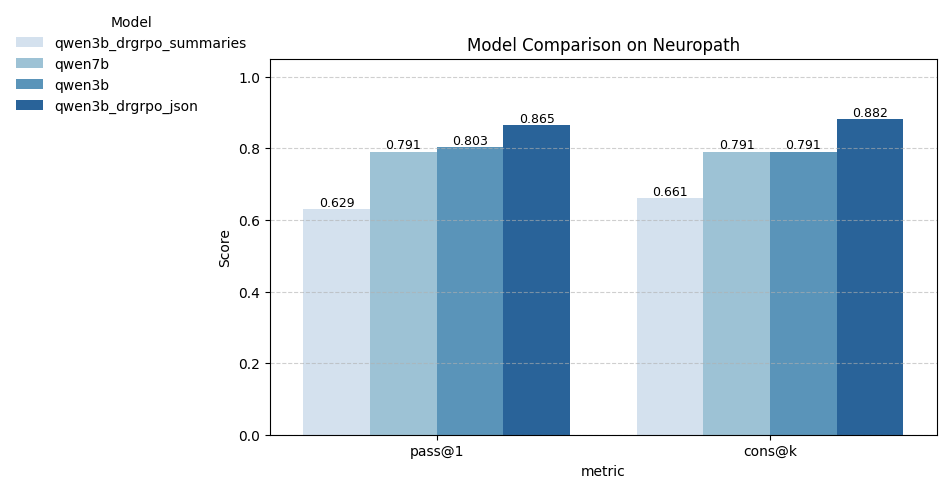

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_sorted, x='metric', y='score', hue='model', palette="Blues")

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', label_type='edge', fontsize=9)

plt.ylim(0, 1.05)
plt.ylabel("Score")
# plt.title("Model Comparison on Cognitive Status")
plt.title("Model Comparison on Neuropath")

# Move legend outside to the top left
plt.legend(title='Model', loc='upper left', bbox_to_anchor=(-0.4, 1.15), frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
